<div align="center">

#####

#**Teoría de Circuitos 2**

##**Trabajo Práctico N°4**

**Estudiante: Nahir Lewartowski**

</div>

---


###**Atenuación normalizada**

Frecuencia central: $f_0 = 22 \text{ kHz}$

Factor de calidad: $Q = 5$

Frecuencias de detención: $f_{s1} = 17 \text{ kHz}$ y $f_{s2} = 36 \text{ kHz}$

Atenuación máxima: $\alpha_{max} = 0.5 \text{ dB}$

Atenuaciones mínimas: $\alpha_{min1} = 16 \text{ dB}$ y $\alpha_{min2} = 24 \text{ dB}$

$$\omega = Q \cdot \frac{f^2 - f_0^2}{f \cdot f_0}$$

Para $f_{s1} = 17 \text{ kHz}$:

$$\omega_{s1} = 5 \cdot \frac{17^2 - 22^2}{17 \cdot 22} \approx -2.607$$

Para $f_{s2} = 36 \text{ kHz}$:

$$\omega_{s2} = 5 \cdot \frac{36^2 - 22^2}{36 \cdot 22} \approx 5.126$$

$$ϵ^2 = 10^{α_{max}/10} - 1 ≈ 0.122$$

$$α_{min} = 10 ⋅ log[1 + ϵ^2 ⋅ cosh^2(n ⋅ cosh^{-1} ω_s)]$$

Para n = 1 y $|\omega_{s1}| = 2.607$: $α_{min} ≈ 2.623$

Para n = 2 y $|\omega_{s1}| = 2.607$: $α_{min} ≈ 13.085$

Para n = 3 y $|\omega_{s1}| = 2.607$: $α_{min} ≈ 26.867$

n = 3 para $\omega_{s1}$.

Para n = 1 y $\omega_{s2} = 5.126$: $α_{min} ≈ 6.238$

Para n = 2 y $\omega_{s2} = 5.126$: $α_{min} ≈ 25.122$

Para n = 3 y $\omega_{s2} = 5.126$: $α_{min} ≈ 45.240$

n = 2 para $\omega_{s2}$.

Para cumplir el caso más restrictivo debería usar n=3, pero al aplicar la transformación pasabanda se duplicarían llegando a 6. El caso más restrictivo con n=2 llega a $α_{min} ≈ 13.085$, apenas 3dB menos que el requisito. A fines de simplificar el diseño, usaré n=2 que se aproxima a los requisitos.




###**Función transferencia normalizada**

$$ϵ = \sqrt{10^{α_{max}/10} - 1} ≈ 0.349$$

$$a = \frac{1}{n} \sinh^{-1}\left(\frac{1}{\epsilon}\right) \approx 0.887$$

$$\theta_k = \frac{(2k-1)\pi}{2n}$$

$$\sigma_k = -\sinh(a)\sin(\theta_k)$$

$$\omega_k = \cosh(a)\cos(\theta_k)$$

$$Polo\,\, s_k=\sigma_k+j\omega_k$$

$$s_k = -\sinh(a)\sin(\frac{(2k-1)\pi}{4}) + j \cosh(a)\cos(\frac{(2k-1)\pi}{4})$$

$$s_1 = -0.713 - j \,1.004$$

$$s_2 = -0.713 + j \,1.004$$

$$(s - s_1) ⋅ (s - s_2) = (s + 0.713 + j \,1.004) ⋅ (s + 0.713 - j \,1.004) = s^2 + 1.426s + 1.516$$

$$T_{LP}(s) = \frac{(\sigma^2 + \omega^2) / (\sqrt{1+\epsilon^2})}{(s - s_1) ⋅ (s - s_2)} = \frac{1.431}{s^2 + 1.426s + 1.516} $$

###**Transformación pasabanda**

$$T_{BP}(s') = \frac{1.431}{s'^2 + 1.426s' + 1.516} $$

Núcleo de transformación:

$$s' = Q \cdot \frac{s^2 + 1}{s} = 5 \cdot \frac{s^2 + 1}{s}$$

$$T_{BP}(s) = \frac{1.431}{(5 \cdot \frac{s^2 + 1}{s})^2 + 1.426\cdot 5 \cdot \frac{s^2 + 1}{s} + 1.516} = \frac{0.05724 s^2}{s^4 + 0.2852s^3 + 2.06064s^2 + 0.2852s + 1}$$

$$s^4 + As^3 + Bs^2 + As + 1$$

donde $A = 0.2852$ y $B = 2.06064$

$x = \omega_1 + \omega_2$

$$x^2 = \frac{B+2 + \sqrt{(B+2)^2 - 4A^2}}{2}$$

$$ x = 2.0101$$

$$Q_{SOS} = \frac{x}{A} = 7.048$$

$$\omega^2 - x\omega + 1 = 0$$

Aplico resolvente:

$$\omega_1 = 1.1056$$

$$\omega_2 = 0.9044$$

$$\omega_1^2 \approx 1.222$$

$$\omega_2^2 \approx 0.818$$

$$T_{BP}(s) = \left( \frac{K_1 s}{s^2 + \frac{\omega_1}{Q_{SOS}}s + \omega_1^2} \right) \cdot \left( \frac{K_2 s}{s^2 + \frac{\omega_2}{Q_{SOS}}s + \omega_2^2} \right) = \left( \frac{K_1 s}{s^2 + 0.1569s + 1.222} \right) \cdot \left( \frac{K_2 s}{s^2 + 0.1283s + 0.818} \right)$$

con $K_1 \cdot K_2 = 0.05724$

asumo $K_1 = K_2 \approx 0.2392$

$$T_1(s) = \frac{0.2392 s}{s^2 + 0.1569s + 1.222}$$

$$T_2(s) = \frac{0.2392 s}{s^2 + 0.1283s + 0.818}$$

###**Simulación en Python**


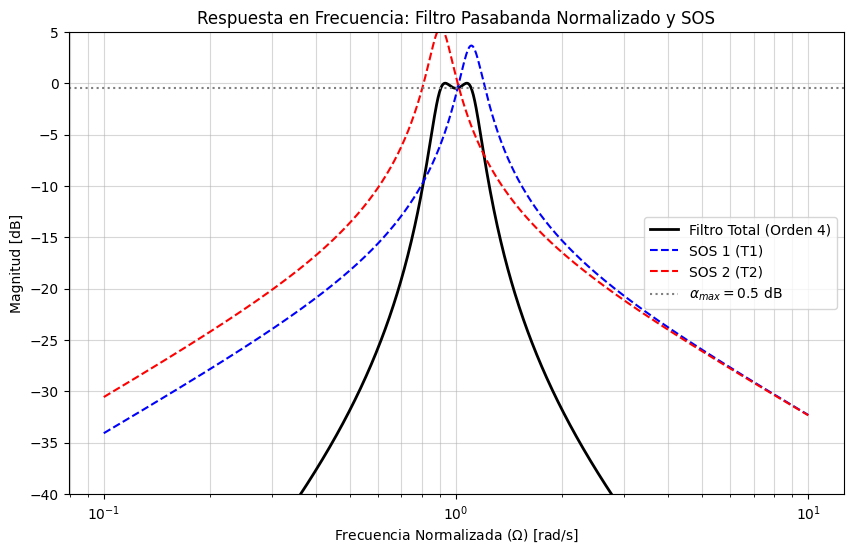

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

num_total = [0.05724, 0, 0]
den_total = [1, 0.2852, 2.06064, 0.2852, 1]
sys_total = signal.TransferFunction(num_total, den_total)

num_sos1 = [0.2392, 0]
den_sos1 = [1, 0.1569, 1.222]
sys_sos1 = signal.TransferFunction(num_sos1, den_sos1)

num_sos2 = [0.2392, 0]
den_sos2 = [1, 0.1283, 0.818]
sys_sos2 = signal.TransferFunction(num_sos2, den_sos2)

w = np.logspace(-1, 1, 1000)

w_tot, mag_tot, _ = signal.bode(sys_total, w)
w_1, mag_1, _ = signal.bode(sys_sos1, w)
w_2, mag_2, _ = signal.bode(sys_sos2, w)

plt.figure(figsize=(10, 6))
plt.semilogx(w_tot, mag_tot, label='Filtro Total (Orden 4)', color='black', linewidth=2)
plt.semilogx(w_1, mag_1, label='SOS 1 (T1)', linestyle='--', color='blue')
plt.semilogx(w_2, mag_2, label='SOS 2 (T2)', linestyle='--', color='red')

plt.title('Respuesta en Frecuencia: Filtro Pasabanda Normalizado y SOS')
plt.xlabel(r'Frecuencia Normalizada ($\Omega$) [rad/s]')
plt.ylabel('Magnitud [dB]')
plt.axhline(-0.5, color='gray', linestyle=':', label=r'$\alpha_{max} = 0.5$ dB')
plt.ylim(-40, 5)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

###**Simulación del filtro pasabanda**

*   Para el SOS 1:

$s^2 + 0.1569s + 1.222 = s^2 + \frac{R_1}{L_1}s + \frac{1}{L_1C_1}$

Asumo $L_1 = 1H$

$\frac{R_1}{L_1} = 0.1569 ⇒ R_1 = 0.1569Ω$

$\frac{1}{L_1C_1} = 1.222 ⇒ C_1 = 0.8183F$

*   Para el SOS 2:

$s^2 + 0.1283s + 0.818 = s^2 + \frac{R_2}{L_2}s + \frac{1}{L_2C_2}$

Asumo $L_2 = 1H$

$\frac{R_2}{L_2} = 0.1283 ⇒ R_2 = 0.1283Ω$

$\frac{1}{L_2C_2} = 0.818 ⇒ C_2 = 1.2225F$

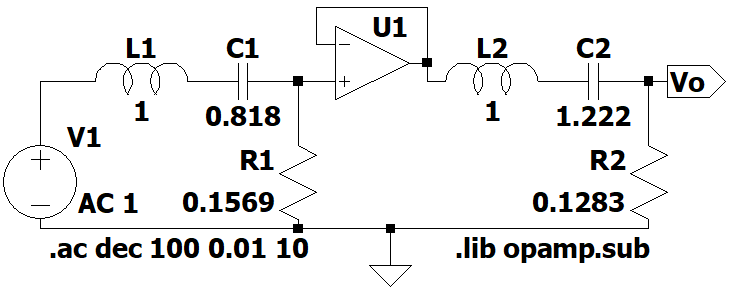

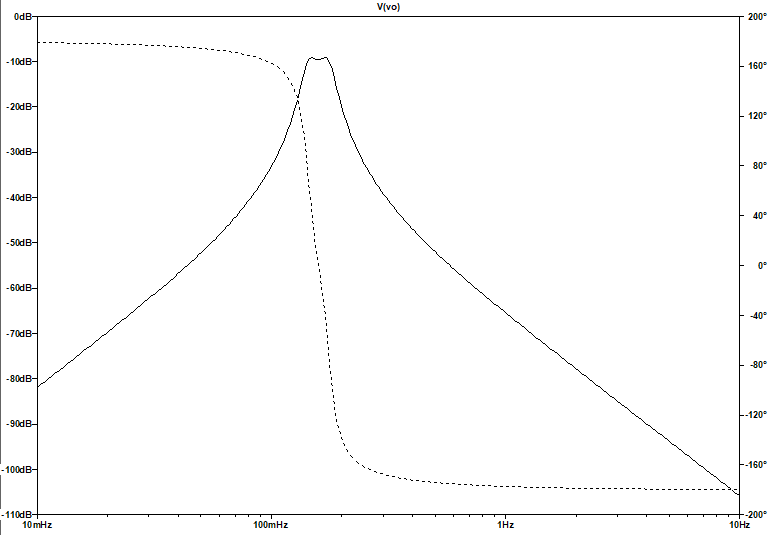

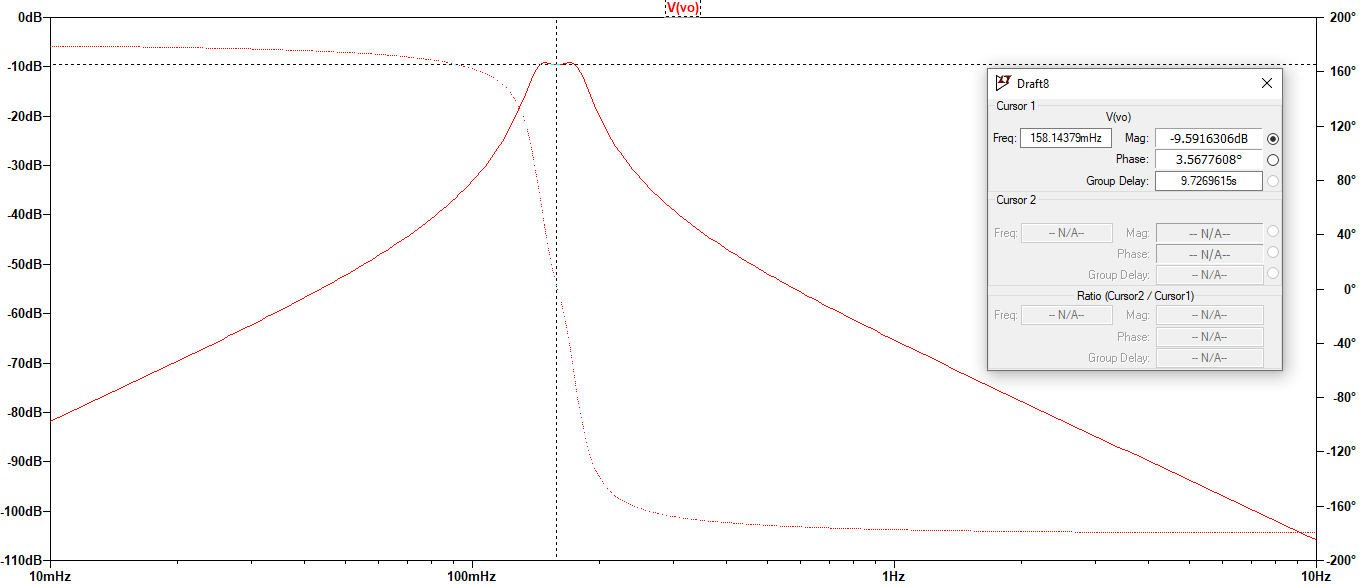

$K_{real} = R_1 \cdot R_2 = 0.1569 \cdot 0.1283 = 0.02013$

$\displaystyle \frac{K_{real}}{K_{teórico}} = \frac{0.02013}{0.05724} = 0.3516$

Pasado a dB: $20 log (0.3516) = -9.08dB$

El formato del filtro coincide visualmente con lo obtenido mediante Python; se observa claramente que el centro del pasabanda ronda los -9.59dB, esto se debe a el $K_{real}$ es menor al $K_{teórico}$, lo que termina representando una pérdida de -9.08dB, esto sumado a los -0.5dB del diseño coinciden con la simulación.





###**Transformación pasa-altos**

$$T_{HP}(s) = T_{LP}(\frac{1}{s})$$

$$T_{HP}(s) = \frac{1.431}{\left(\frac{1}{s}\right)^2 + 1.426\left(\frac{1}{s}\right) + 1.516}$$

$$T_{HP}(s) = \frac{1.431s^2}{1 + 1.426s + 1.516s^2}$$

$$T_{HP}(s) = \frac{0.9439s^2}{s^2 + 0.9406s + 0.6596}$$

###**Conclusión**

Para el diseño del filtro pasabajos se optó por un orden menor al estrictamente requerido por la plantilla, priorizando así la simplicidad del circuito resultante tras la transformación a pasabanda. Finalmente, los resultados obtenidos en las simulaciones de Python y LTspice verifican el éxito del diseño propuesto.